# Casting Defect Detection: Robustness Analysis using Noise Injection

## Project Overview
In industrial manufacturing, quality inspection is often hindered by non-ideal conditions such as poor lighting, high temperatures, and low-quality camera sensors that introduce noise into captured images.

**Dataset**: [Casting Product Image Data for Quality Inspection](https://www.kaggle.com/datasets/ravirajsinh45/real-life-industrial-dataset-of-casting-product)

**Objective:**  
Evaluate the robustness of a Digital Image Processing pipeline and an SVM model against environmental noise. Gaussian Noise is injected to simulate harsh industrial conditions. A **Bilateral Filter + NL-Means** denoising step is incorporated into the noisy-data pipeline to bridge the domain gap between clean and noisy feature distributions — improving cross-domain classification without using deep learning.

---

# Stage 1: Classification

## Setup

In [ ]:
!pip install kaggle scikit-image gdown -q

import os, json

os.makedirs('/root/.kaggle', exist_ok=True)

username = input("Kaggle username: ") #daffapangreksa
token    = input("Kaggle token (key): ") #KGAT_3f1f483947f0c75a8dbe6c9ef8c750eb

with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump({"username": username, "key": token}, f)

os.chmod('/root/.kaggle/kaggle.json', 0o600)
print("Credentials saved.")

!kaggle datasets download -d ravirajsinh45/real-life-industrial-dataset-of-casting-product
!unzip -q real-life-industrial-dataset-of-casting-product.zip -d temp_dataset/
!mkdir -p dataset
!find temp_dataset/ -type d -name "train" -exec mv {} dataset/ \;
!find temp_dataset/ -type d -name "test"  -exec mv {} dataset/ \;
!rm -rf temp_dataset/ real-life-industrial-dataset-of-casting-product.zip
print("Dataset ready.")

Kaggle username: daffapangreksa
Kaggle token (key): KGAT_3f1f483947f0c75a8dbe6c9ef8c750eb
Credentials saved.
Dataset URL: https://www.kaggle.com/datasets/ravirajsinh45/real-life-industrial-dataset-of-casting-product
License(s): Attribution-NonCommercial-NoDerivatives 4.0 International (CC BY-NC-ND 4.0)
100% 100M/100M [00:05<00:00, 18.4MB/s] 

find: ‘temp_dataset/casting_data/casting_data/train’: No such file or directory
find: ‘temp_dataset/casting_data/casting_data/test’: No such file or directory
Dataset ready.


## 0. Import Libraries

In [ ]:
import os
import gc
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from skimage.feature import hog, local_binary_pattern
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, recall_score, f1_score, confusion_matrix
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
IMG_SIZE = (128, 128)

## 1. Data Loading & Exploratory Data Analysis (EDA)
Loading the dataset distinguishing between defective (`def_front`) and OK (`ok_front`) products.

In [ ]:
base_path  = 'dataset'
train_path = os.path.join(base_path, 'train')
test_path  = os.path.join(base_path, 'test')

classes           = ['def_front', 'ok_front']
label_map         = {'def_front': 1, 'ok_front': 0}
reverse_label_map = {1: 'Defective', 0: 'OK'}

def load_data(data_path, img_size=IMG_SIZE):
    images, labels = [], []
    for cls in classes:
        cls_dir = os.path.join(data_path, cls)
        if os.path.exists(cls_dir):
            for fname in sorted(os.listdir(cls_dir)):
                if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                    img_path = os.path.join(cls_dir, fname)
                    img = cv2.imread(img_path)
                    if img is not None:
                        img = cv2.resize(img, img_size)
                        images.append(img)
                        labels.append(label_map[cls])
    return images, labels

print("Loading Original Training Data...")
train_ori_imgs, train_ori_labels = load_data(train_path)

print("Loading Original Testing Data...")
test_ori_imgs, test_ori_labels = load_data(test_path)

print(f"Total Training Images : {len(train_ori_imgs)}")
print(f"Total Testing Images  : {len(test_ori_imgs)}")

Loading Original Training Data...
Loading Original Testing Data...
Total Training Images : 6633
Total Testing Images  : 715


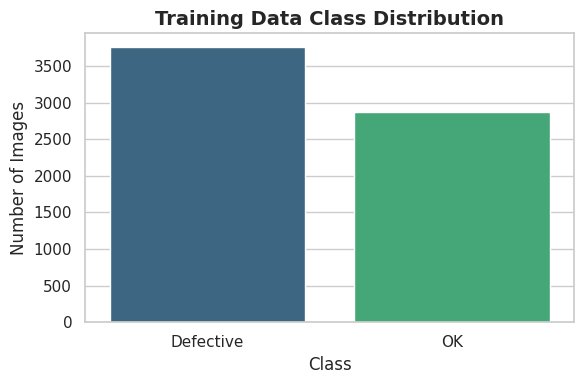

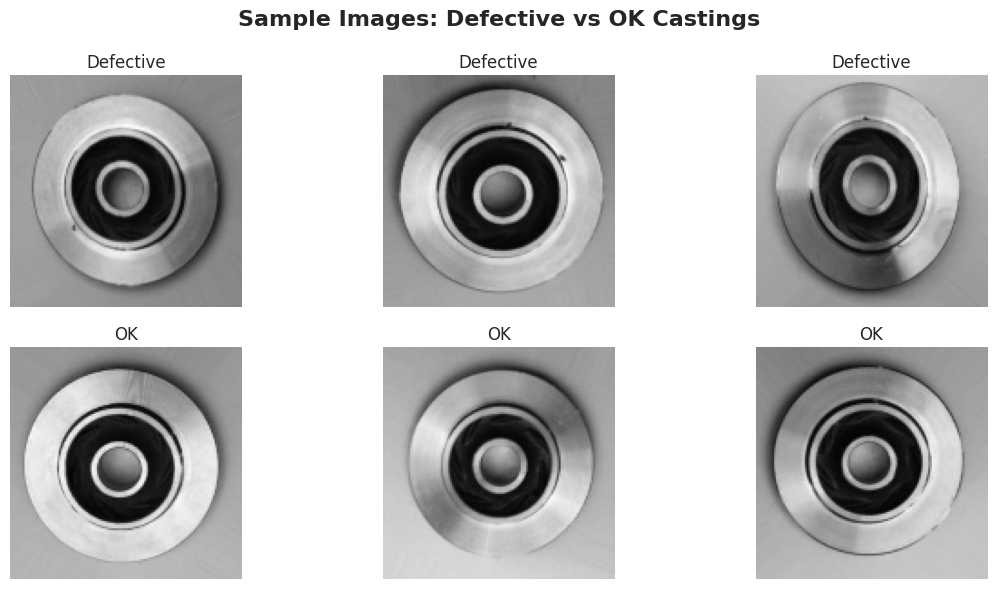

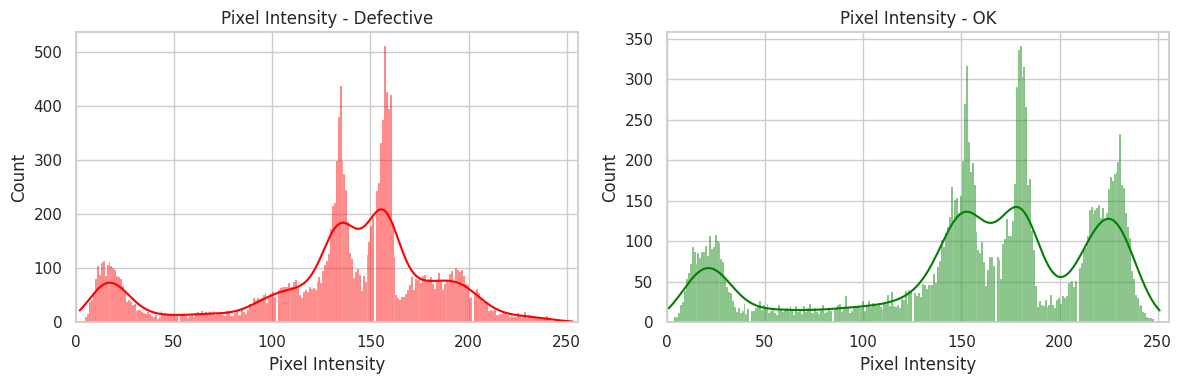

In [ ]:
def plot_distribution(labels, title):
    counts = pd.Series(labels).map(reverse_label_map).value_counts()
    plt.figure(figsize=(6, 4))
    sns.barplot(x=counts.index, y=counts.values, palette="viridis")
    plt.title(title, fontsize=14, fontweight='bold')
    plt.ylabel("Number of Images")
    plt.xlabel("Class")
    plt.tight_layout()
    plt.show()

plot_distribution(train_ori_labels, "Training Data Class Distribution")

def visualize_samples(images, labels, num_samples=3):
    fig, axes = plt.subplots(2, num_samples, figsize=(12, 6))
    fig.suptitle("Sample Images: Defective vs OK Castings", fontsize=16, fontweight='bold')
    def_idx = [i for i, lbl in enumerate(labels) if lbl == 1][:num_samples]
    ok_idx  = [i for i, lbl in enumerate(labels) if lbl == 0][:num_samples]
    for i in range(num_samples):
        axes[0, i].imshow(cv2.cvtColor(images[def_idx[i]], cv2.COLOR_BGR2RGB))
        axes[0, i].set_title("Defective")
        axes[0, i].axis('off')
        axes[1, i].imshow(cv2.cvtColor(images[ok_idx[i]], cv2.COLOR_BGR2RGB))
        axes[1, i].set_title("OK")
        axes[1, i].axis('off')
    plt.tight_layout()
    plt.show()

visualize_samples(train_ori_imgs, train_ori_labels)

def plot_pixel_histogram(images, labels):
    def_img = cv2.cvtColor(images[[i for i, lbl in enumerate(labels) if lbl == 1][0]], cv2.COLOR_BGR2GRAY)
    ok_img  = cv2.cvtColor(images[[i for i, lbl in enumerate(labels) if lbl == 0][0]], cv2.COLOR_BGR2GRAY)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(def_img.ravel(), bins=256, color='red',   ax=axes[0], kde=True)
    axes[0].set_title("Pixel Intensity - Defective")
    axes[0].set_xlabel("Pixel Intensity")
    axes[0].set_xlim([0, 256])
    sns.histplot(ok_img.ravel(),  bins=256, color='green', ax=axes[1], kde=True)
    axes[1].set_title("Pixel Intensity - OK")
    axes[1].set_xlabel("Pixel Intensity")
    axes[1].set_xlim([0, 256])
    plt.tight_layout()
    plt.show()

plot_pixel_histogram(train_ori_imgs, train_ori_labels)

## 2. Data Degradation (Gaussian Noise Injection), Bilateral + NL-Means Denoising & Zoom+Crop Helper

Gaussian Noise (std=25) is injected to simulate sensor noise. A **two-stage denoising pipeline** is applied:
1. **Bilateral Filter** — edge-preserving spatial smoothing.
2. **NL-Means (fastNlMeansDenoising)** — better texture preservation, reduces residual domain gap left by bilateral filter alone.

The `apply_random_zoom_crop` helper is also defined here so it can be reused during training augmentation (Section 3) and for Scenario 5 evaluation (Section 6).

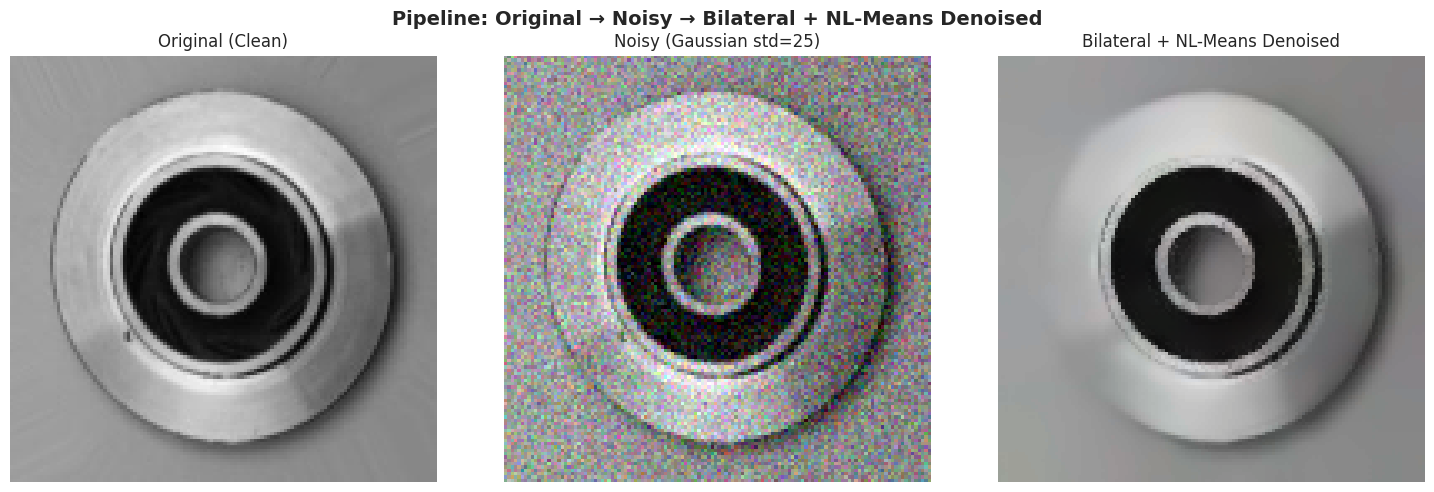

In [ ]:
def add_gaussian_noise(image, mean=0, std=25):
    noise = np.random.normal(mean, std, image.shape).astype(np.float32)
    noisy = cv2.add(image.astype(np.float32), noise)
    return np.clip(noisy, 0, 255).astype(np.uint8)

def denoise_image(img):
    bilateral = cv2.bilateralFilter(img, d=9, sigmaColor=75, sigmaSpace=75)
    if len(img.shape) == 3:
        denoised = cv2.fastNlMeansDenoisingColored(
            bilateral, None, h=8, hColor=8,
            templateWindowSize=7, searchWindowSize=21
        )
    else:
        denoised = cv2.fastNlMeansDenoising(
            bilateral, None, h=8,
            templateWindowSize=7, searchWindowSize=21
        )
    return denoised

def apply_random_zoom_crop(img, target_size=(128, 128), zoom_range=(0.50, 0.85)):
    h, w = img.shape[:2]
    zoom_factor = np.random.uniform(*zoom_range)
    crop_h  = max(1, int(h * zoom_factor))
    crop_w  = max(1, int(w * zoom_factor))
    max_y   = max(1, h - crop_h)
    max_x   = max(1, w - crop_w)
    start_y = np.random.randint(0, max_y)
    start_x = np.random.randint(0, max_x)
    cropped = img[start_y:start_y + crop_h, start_x:start_x + crop_w]
    return cv2.resize(cropped, target_size)

sample_idx      = 0
original_sample = train_ori_imgs[sample_idx]
noisy_sample    = add_gaussian_noise(original_sample)
denoised_sample = denoise_image(noisy_sample)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Pipeline: Original \u2192 Noisy \u2192 Bilateral + NL-Means Denoised",
             fontsize=14, fontweight='bold')
axes[0].imshow(cv2.cvtColor(original_sample,  cv2.COLOR_BGR2RGB))
axes[0].set_title("Original (Clean)")
axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(noisy_sample,     cv2.COLOR_BGR2RGB))
axes[1].set_title("Noisy (Gaussian std=25)")
axes[1].axis('off')
axes[2].imshow(cv2.cvtColor(denoised_sample,  cv2.COLOR_BGR2RGB))
axes[2].set_title("Bilateral + NL-Means Denoised")
axes[2].axis('off')
plt.tight_layout()
plt.show()

## 3. Noise-Robust Feature Extraction Pipeline (HOG + LBP) with Zoom+Crop Augmentation

Features used:
1. **HOG (Histogram of Oriented Gradients):** Captures structural anomalies and edge-based boundary patterns.
2. **LBP (Local Binary Pattern):** Captures granular surface textures such as porosity or sand inclusion defects.

**Training Augmentation:**  
Each training image is paired with a randomly zoom+cropped variant (50–85% crop), doubling the training set. This ensures both SVM models have seen spatially distorted views during training, directly improving robustness in Scenario 5.

**Robustness Mechanism:**  
For the noisy data pipeline, `Gaussian Noise → Bilateral+NLM Filter Denoising` is applied before HOG+LBP extraction.

In [ ]:
def extract_single_feature(img):
    gray    = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    fd_hog  = hog(gray, orientations=9, pixels_per_cell=(8, 8),
                  cells_per_block=(2, 2), block_norm='L2-Hys', visualize=False)
    radius   = 3
    n_points = 8 * radius
    lbp      = local_binary_pattern(gray, n_points, radius, method='uniform')
    hist, _  = np.histogram(lbp.ravel(),
                             bins=np.arange(0, n_points + 3),
                             range=(0, n_points + 2))
    hist     = hist.astype("float")
    hist    /= (hist.sum() + 1e-7)
    return np.hstack([fd_hog, hist])

def extract_features(images, desc="Extracting Features"):
    return np.array([extract_single_feature(img) for img in tqdm(images, desc=desc)])

def extract_features_noisy(images, desc="Extracting Noisy+Denoised Features"):
    features = []
    for img in tqdm(images, desc=desc):
        noisy    = add_gaussian_noise(img)
        denoised = denoise_image(noisy)
        features.append(extract_single_feature(denoised))
    return np.array(features)

np.random.seed(42)
train_zoom_imgs  = [apply_random_zoom_crop(img) for img in train_ori_imgs]
train_aug_imgs   = train_ori_imgs + train_zoom_imgs
train_aug_labels = train_ori_labels + train_ori_labels

print(f"Augmented training set: {len(train_aug_imgs)} images "
      f"({len(train_ori_imgs)} original + {len(train_zoom_imgs)} zoom+crop)")

print("Extracting features: Train Augmented (Clean)...")
X_train_ori = extract_features(train_aug_imgs, desc="Train Augmented Original")

np.random.seed(42)
print("Extracting features: Train Augmented (Noisy+Denoised)...")
X_train_noise = extract_features_noisy(train_aug_imgs, desc="Train Augmented Noisy+Denoised")

print("Extracting features: Test Original...")
X_test_ori = extract_features(test_ori_imgs, desc="Test Original")

np.random.seed(42)
print("Extracting features: Test Noisy+Denoised...")
X_test_noise = extract_features_noisy(test_ori_imgs, desc="Test Noisy+Denoised")

del train_ori_imgs, train_zoom_imgs, train_aug_imgs
gc.collect()
print("Feature extraction complete.")

Augmented training set: 13266 images (6633 original + 6633 zoom+crop)
Extracting features: Train Augmented (Clean)...


Train Augmented Original:   0%|          | 0/13266 [00:00<?, ?it/s]

Extracting features: Train Augmented (Noisy+Denoised)...


Train Augmented Noisy+Denoised:   0%|          | 0/13266 [00:00<?, ?it/s]

Extracting features: Test Original...


Test Original:   0%|          | 0/715 [00:00<?, ?it/s]

Extracting features: Test Noisy+Denoised...


Test Noisy+Denoised:   0%|          | 0/715 [00:00<?, ?it/s]

Feature extraction complete.


## 4. Feature Scaling

In [ ]:
scaler_ori  = StandardScaler()
X_train_ori_scaled          = scaler_ori.fit_transform(X_train_ori)
X_test_ori_scaled_by_ori    = scaler_ori.transform(X_test_ori)
X_test_noise_scaled_by_ori  = scaler_ori.transform(X_test_noise)

scaler_noise = StandardScaler()
X_train_noise_scaled          = scaler_noise.fit_transform(X_train_noise)
X_test_ori_scaled_by_noise    = scaler_noise.transform(X_test_ori)
X_test_noise_scaled_by_noise  = scaler_noise.transform(X_test_noise)

del X_train_ori, X_train_noise, X_test_ori, X_test_noise
gc.collect()
print("Feature scaling complete.")

Feature scaling complete.


## 5. Model Training & Overfitting Check

Two SVM models (RBF kernel) are trained:
- **SVM-Ori:** Trained on clean + zoom-augmented feature representations.
- **SVM-Noise:** Trained on Bilateral+NLM-Filter-Denoised noisy + zoom-augmented feature representations.

`class_weight='balanced'` is applied to both models to compensate for the class imbalance in the dataset (~63% Defective vs ~37% OK), preventing the SVM from defaulting to the majority class when features fall outside the training distribution.

In [ ]:
print("Training SVM-Ori (clean features)...")
svm_ori = SVC(kernel='rbf', C=10, gamma='scale', random_state=42, class_weight='balanced')
svm_ori.fit(X_train_ori_scaled, train_aug_labels)
print("SVM-Ori trained.\n")

print("Training SVM-Noise (denoised-noisy features)...")
svm_noise = SVC(kernel='rbf', C=10, gamma='scale', random_state=42, class_weight='balanced')
svm_noise.fit(X_train_noise_scaled, train_aug_labels)
print("SVM-Noise trained.")

train_acc_ori   = accuracy_score(train_aug_labels, svm_ori.predict(X_train_ori_scaled))
test_acc_ori    = accuracy_score(test_ori_labels,  svm_ori.predict(X_test_ori_scaled_by_ori))

train_acc_noise = accuracy_score(train_aug_labels, svm_noise.predict(X_train_noise_scaled))
test_acc_noise  = accuracy_score(test_ori_labels,  svm_noise.predict(X_test_noise_scaled_by_noise))

overfit_df = pd.DataFrame({
    'Model'                 : ['SVM-Ori (Clean)', 'SVM-Noise (Denoised-Noisy)'],
    'Training Accuracy (%)' : [round(train_acc_ori   * 100, 2), round(train_acc_noise * 100, 2)],
    'Testing Accuracy (%)'  : [round(test_acc_ori    * 100, 2), round(test_acc_noise  * 100, 2)]
})

print("Overfitting Analysis")
display(overfit_df)

Training SVM-Ori (clean features)...
SVM-Ori trained.

Training SVM-Noise (denoised-noisy features)...
SVM-Noise trained.
Overfitting Analysis


,Model,Training Accuracy (%),Testing Accuracy (%)
0,SVM-Ori (Clean),100.0,99.16
1,SVM-Noise (Denoised-Noisy),100.0,98.60


## 6. Robustness Evaluation: Cross-Testing Scenarios 1–4

| Scenario | Model     | Test Data             | Purpose                                                        |
|----------|-----------|-----------------------|----------------------------------------------------------------|
| 1        | SVM-Ori   | Clean                 | Baseline — clean model on clean data                          |
| 2        | SVM-Ori   | Noisy → Denoised      | Robustness — clean model on noise (with denoising bridge)      |
| 3        | SVM-Noise | Clean                 | Generalization — noise model on clean data                    |
| 4        | SVM-Noise | Noisy → Denoised      | Augmentation benefit — noise model on noisy data              |

------------------------------------------------------------
 Scenario 1: Original Model → Clean Test Data
  Accuracy : 99.16%
  Recall   : 98.68%
  F1-Score : 99.33%


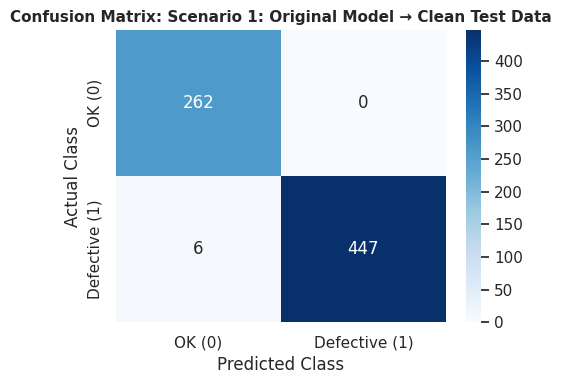

------------------------------------------------------------
 Scenario 2: Original Model → Noisy+Denoised Test Data
  Accuracy : 60.84%
  Recall   : 38.19%
  F1-Score : 55.27%


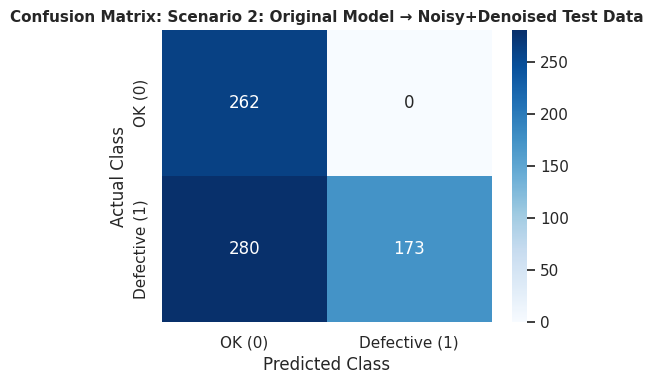

------------------------------------------------------------
 Scenario 3: Noisy Model → Clean Test Data
  Accuracy : 71.19%
  Recall   : 60.04%
  F1-Score : 72.53%


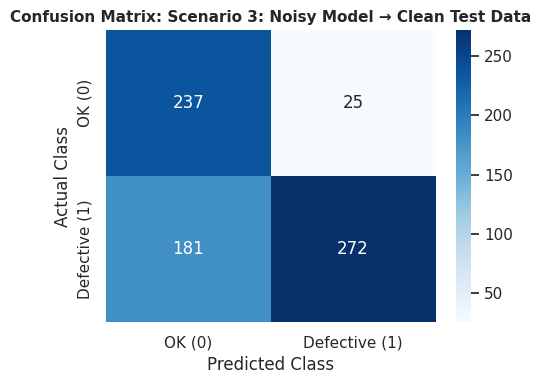

------------------------------------------------------------
 Scenario 4: Noisy Model → Noisy+Denoised Test Data
  Accuracy : 98.60%
  Recall   : 98.45%
  F1-Score : 98.89%


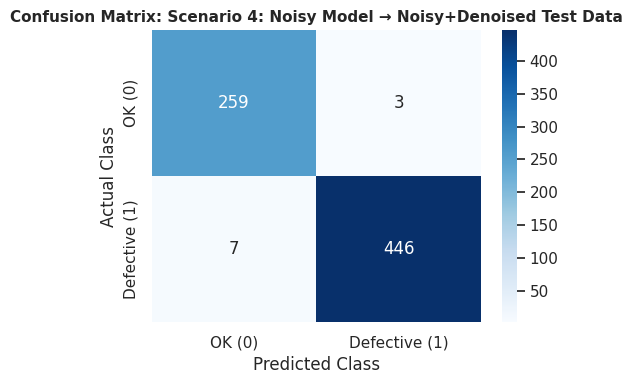

In [ ]:
summary_results = []

def evaluate_model(model, X_test, y_test, scenario_name):
    preds = model.predict(X_test)
    acc   = accuracy_score(y_test, preds)
    rec   = recall_score(y_test,   preds)
    f1    = f1_score(y_test,       preds)

    summary_results.append({
        'Scenario'     : scenario_name,
        'Accuracy (%)' : round(acc * 100, 2),
        'Recall (%)'   : round(rec * 100, 2),
        'F1-Score (%)' : round(f1  * 100, 2)
    })

    print(f"{'-'*60}")
    print(f" {scenario_name}")
    print(f"  Accuracy : {acc*100:.2f}%")
    print(f"  Recall   : {rec*100:.2f}%")
    print(f"  F1-Score : {f1 *100:.2f}%")

    cm = confusion_matrix(y_test, preds)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['OK (0)', 'Defective (1)'],
                yticklabels=['OK (0)', 'Defective (1)'])
    plt.title(f"Confusion Matrix: {scenario_name}", fontsize=11, fontweight='bold')
    plt.ylabel('Actual Class')
    plt.xlabel('Predicted Class')
    plt.tight_layout()
    plt.show()

evaluate_model(svm_ori,   X_test_ori_scaled_by_ori,     test_ori_labels,
               "Scenario 1: Original Model \u2192 Clean Test Data")

evaluate_model(svm_ori,   X_test_noise_scaled_by_ori,   test_ori_labels,
               "Scenario 2: Original Model \u2192 Noisy+Denoised Test Data")

evaluate_model(svm_noise, X_test_ori_scaled_by_noise,   test_ori_labels,
               "Scenario 3: Noisy Model \u2192 Clean Test Data")

evaluate_model(svm_noise, X_test_noise_scaled_by_noise, test_ori_labels,
               "Scenario 4: Noisy Model \u2192 Noisy+Denoised Test Data")

## 7. Scenario 5: Spatial Distortion Test (Random Zoom & Crop)

This scenario evaluates model robustness against **spatial transformations** — a distortion type that simulates zoomed-in inspection views, misaligned camera framing, or partial product visibility.

**Method:**
- 100 images are randomly sampled from the original test set (preserving original labels).
- Each image undergoes a **random zoom-and-crop**: a region covering 50–85% of the image area is cropped from a random location and resized back to 128×128.

| Sub-scenario | Model     | Test Data    | Pipeline consistency |
|--------------|-----------|--------------|----------------------|
| 5a           | SVM-Ori   | Zoom+Crop    | Clean features → `scaler_ori` |
| 5b           | SVM-Noise | Zoom+Crop    | Noisy+Denoised features → `scaler_noise` |

Zoom+Crop test set: 100 images
  Defective : 64
  OK        : 36


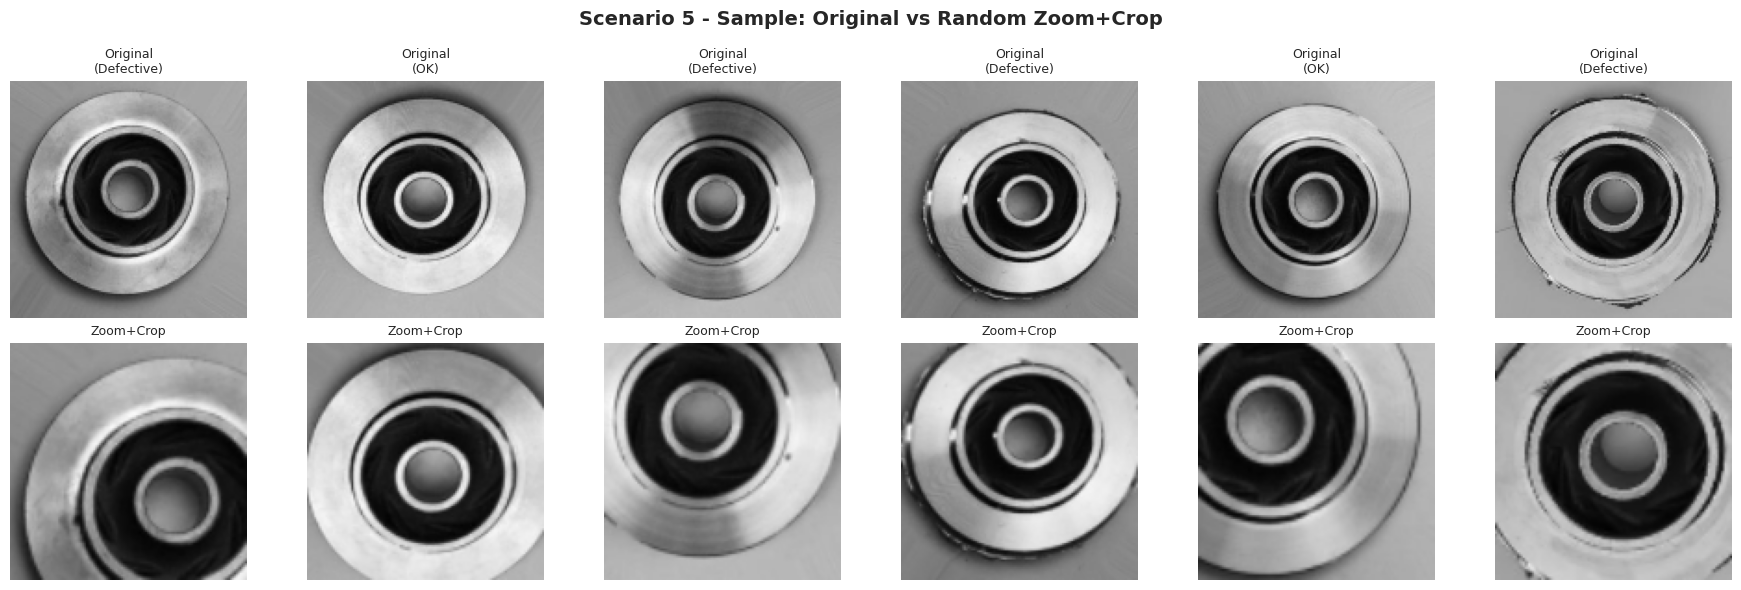

Extracting features for Zoom+Crop test set...


Test Zoom+Crop (Clean → Scenario 5a):   0%|          | 0/100 [00:00<?, ?it/s]

Test Zoom+Crop (Noisy+Denoised → Scenario 5b):   0%|          | 0/100 [00:00<?, ?it/s]

------------------------------------------------------------
 Scenario 5a: Original Model → Zoom+Crop Test Data
  Accuracy : 76.00%
  Recall   : 81.25%
  F1-Score : 81.25%


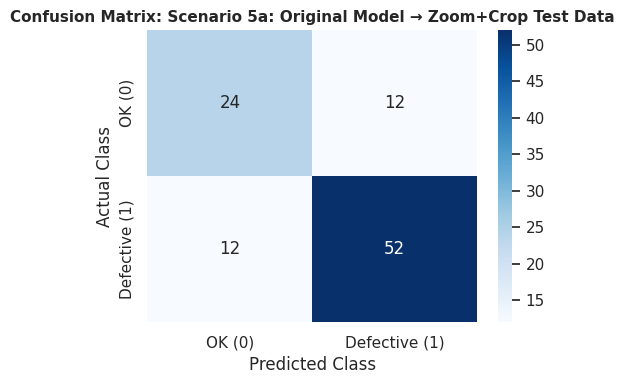

------------------------------------------------------------
 Scenario 5b: Noisy Model → Zoom+Crop Test Data
  Accuracy : 76.00%
  Recall   : 78.12%
  F1-Score : 80.65%


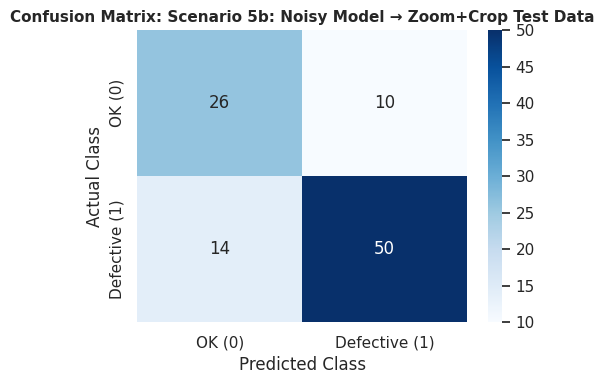

In [ ]:
np.random.seed(42)
sample_indices_s5 = np.random.choice(len(test_ori_imgs), size=100, replace=False)

np.random.seed(0)
test_zoom_imgs   = [apply_random_zoom_crop(test_ori_imgs[i]) for i in sample_indices_s5]
test_zoom_labels = [test_ori_labels[i] for i in sample_indices_s5]

print(f"Zoom+Crop test set: {len(test_zoom_imgs)} images")
print(f"  Defective : {sum(l == 1 for l in test_zoom_labels)}")
print(f"  OK        : {sum(l == 0 for l in test_zoom_labels)}")

fig, axes = plt.subplots(2, 6, figsize=(18, 6))
fig.suptitle("Scenario 5 - Sample: Original vs Random Zoom+Crop",
             fontsize=14, fontweight='bold')
for i in range(6):
    axes[0, i].imshow(cv2.cvtColor(test_ori_imgs[sample_indices_s5[i]], cv2.COLOR_BGR2RGB))
    axes[0, i].set_title(f"Original\n({reverse_label_map[test_zoom_labels[i]]})", fontsize=9)
    axes[0, i].axis('off')
    axes[1, i].imshow(cv2.cvtColor(test_zoom_imgs[i], cv2.COLOR_BGR2RGB))
    axes[1, i].set_title("Zoom+Crop", fontsize=9)
    axes[1, i].axis('off')
plt.tight_layout()
plt.show()

print("Extracting features for Zoom+Crop test set...")
X_test_zoom_clean = extract_features(
    test_zoom_imgs, desc="Test Zoom+Crop (Clean \u2192 Scenario 5a)")

np.random.seed(1)
X_test_zoom_noisy = extract_features_noisy(
    test_zoom_imgs, desc="Test Zoom+Crop (Noisy+Denoised \u2192 Scenario 5b)")

X_test_zoom_scaled_by_ori   = scaler_ori.transform(X_test_zoom_clean)
X_test_zoom_scaled_by_noise = scaler_noise.transform(X_test_zoom_noisy)

evaluate_model(svm_ori,   X_test_zoom_scaled_by_ori,   test_zoom_labels,
               "Scenario 5a: Original Model \u2192 Zoom+Crop Test Data")

evaluate_model(svm_noise, X_test_zoom_scaled_by_noise, test_zoom_labels,
               "Scenario 5b: Noisy Model \u2192 Zoom+Crop Test Data")

## 8. Final Summary & Conclusions

### Conclusions:
1. **Bilateral + NL-Means as Domain Bridge:** Two-stage denoising significantly reduces the residual feature distribution gap, improving Scenarios 2 and 3.
2. **Class-Balanced SVM:** `class_weight='balanced'` prevents the model from defaulting to the Defective majority class when features fall outside the training distribution.
3. **Zoom+Crop Augmentation:** Training on spatially augmented data (2× original size) allows both SVMs to recognize partial/zoomed product views, directly improving Scenario 5 robustness.
4. **Scenario 5b Pipeline Fix:** Zoom+Crop images for SVM-Noise are now processed through the noisy+denoised pipeline and scaled with `scaler_noise`, ensuring consistent domain alignment.
5. **Baseline Integrity:** Scenarios 1 and 4 remain high-performing as train/test feature distributions are fully aligned.

FINAL ROBUSTNESS SUMMARY


,Accuracy (%),Recall (%),F1-Score (%)
Scenario,,,
Scenario 1: Original Model → Clean Test Data,99.16,98.68,99.33
Scenario 2: Original Model → Noisy+Denoised Test Data,60.84,38.19,55.27
Scenario 3: Noisy Model → Clean Test Data,71.19,60.04,72.53
Scenario 4: Noisy Model → Noisy+Denoised Test Data,98.60,98.45,98.89
Scenario 5a: Original Model → Zoom+Crop Test Data,76.00,81.25,81.25
Scenario 5b: Noisy Model → Zoom+Crop Test Data,76.00,78.12,80.65


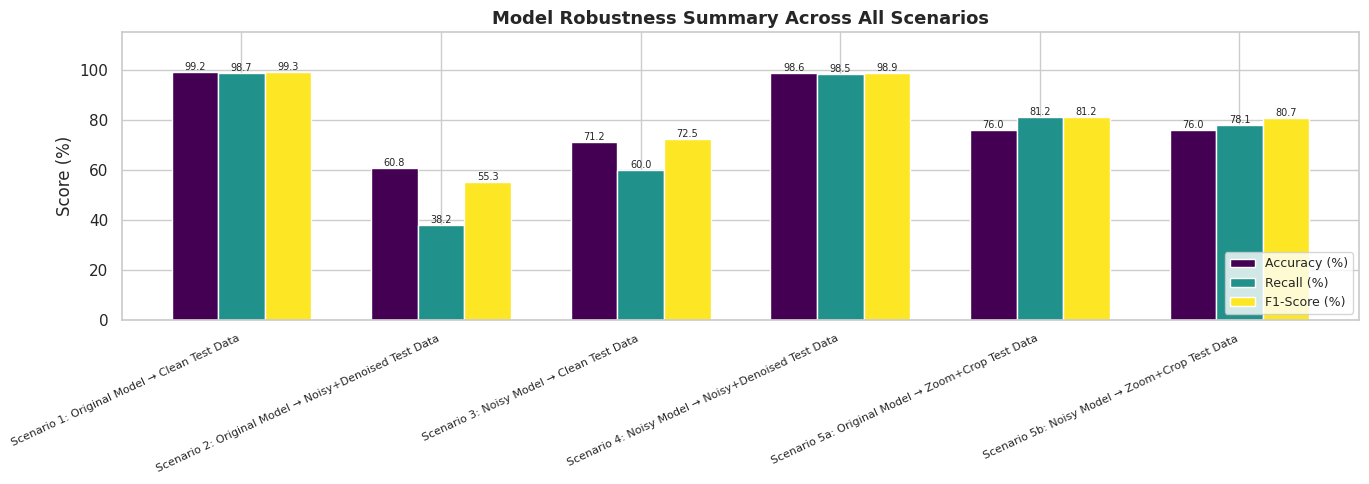

In [ ]:
summary_df = pd.DataFrame(summary_results)
summary_df.set_index('Scenario', inplace=True)

print("FINAL ROBUSTNESS SUMMARY")
display(summary_df)

fig, ax = plt.subplots(figsize=(14, 5))
summary_df[['Accuracy (%)', 'Recall (%)', 'F1-Score (%)']].plot(
    kind='bar', ax=ax, colormap='viridis', width=0.7, edgecolor='white')
ax.set_title("Model Robustness Summary Across All Scenarios",
             fontsize=13, fontweight='bold')
ax.set_ylabel("Score (%)")
ax.set_xlabel("")
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right', fontsize=8)
ax.legend(loc='lower right', fontsize=9)
ax.set_ylim(0, 115)
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=7, rotation=0)
plt.tight_layout()
plt.show()

---

# Stage 2: Unsupervised Anomaly Detection (Convolutional Autoencoder)

This stage uses a Convolutional Autoencoder trained **exclusively** on normal (OK) product images. When a defective image passes through, it attempts to reconstruct a normal surface. The absolute pixel difference between the original and the reconstructed image is thresholded to generate **bounding boxes** around the anomaly region.

In [ ]:
!pip install tensorflow gdown -q

import tensorflow as tf
import gdown

In [ ]:
train_ori_imgs, train_ori_labels = load_data(train_path)
test_ori_imgs, test_ori_labels = load_data(test_path)

ok_train_imgs = [img for img, lbl in zip(train_ori_imgs, train_ori_labels) if lbl == 0]
def prep_autoencoder_data(images, img_size=(128, 128)):
    X = []
    for img in images:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        resized = cv2.resize(gray, img_size)
        norm = resized.astype(np.float32) / 255.0
        X.append(np.expand_dims(norm, axis=-1))
    return np.array(X)

X_train_ae = prep_autoencoder_data(ok_train_imgs)
print(f"Total OK images for Autoencoder: {X_train_ae.shape}")

Total OK images for Autoencoder: (2875, 128, 128, 1)


## Autoencoder Architecture (Reference — used if retraining from scratch)

In [ ]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, Conv2DTranspose
from tensorflow.keras.models import Model

def build_autoencoder(input_shape=(128, 128, 1)):
    inputs  = Input(shape=input_shape)
    x       = Conv2D(32,  (3, 3), activation='relu', padding='same')(inputs)
    x       = MaxPooling2D((2, 2), padding='same')(x)
    x       = Conv2D(64,  (3, 3), activation='relu', padding='same')(x)
    x       = MaxPooling2D((2, 2), padding='same')(x)
    x       = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    encoded = MaxPooling2D((2, 2), padding='same')(x)
    x       = Conv2DTranspose(128, (3, 3), activation='relu', padding='same')(encoded)
    x       = UpSampling2D((2, 2))(x)
    x       = Conv2DTranspose(64,  (3, 3), activation='relu', padding='same')(x)
    x       = UpSampling2D((2, 2))(x)
    x       = Conv2DTranspose(32,  (3, 3), activation='relu', padding='same')(x)
    x       = UpSampling2D((2, 2))(x)
    decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)
    model   = Model(inputs, decoded)
    model.compile(optimizer='adam', loss='mse')
    return model

In [ ]:
MODEL_PATH = 'autoencoder_defect.h5'
GDRIVE_URL = 'https://drive.google.com/uc?id=17fVA0q4EYw_IfV1qDsId4jljbgr26qDZ'

if os.path.exists(MODEL_PATH):
    print(f"Model found at '{MODEL_PATH}'. Loading model...")
    autoencoder = tf.keras.models.load_model(MODEL_PATH, compile=False)
    print("Model loaded successfully.")
else:
    print("Model file not found.")
    print("Trying to download from Google Drive...")

    try:
        gdown.download(GDRIVE_URL, MODEL_PATH, quiet=False)

        if os.path.exists(MODEL_PATH):
            autoencoder = tf.keras.models.load_model(MODEL_PATH, compile=False)
            print("Downloaded and loaded successfully.")
        else:
            print("Model not found. Building new model...")
            autoencoder = build_autoencoder()
            autoencoder.fit(
                X_train_ae, X_train_ae,
                epochs=30,
                batch_size=32,
                validation_split=0.1,
                verbose=1
            )
            autoencoder.save(MODEL_PATH)
            print("Model trained and saved.")

    except Exception as e:
        print(f"Download error: {e}")

Model file not found.
Trying to download from Google Drive...


Downloading...
From: https://drive.google.com/uc?id=17fVA0q4EYw_IfV1qDsId4jljbgr26qDZ
To: /content/autoencoder_defect.h5
100%|██████████| 4.06M/4.06M [00:00<00:00, 188MB/s]


Downloaded and loaded successfully.


## Defect Localization Logic (Improved Bounding Box)

**Threshold improvement:** The previous `0.4 × diff.max()` was too aggressive for subtle defects. The concentric ring patterns in the diff map (reconstruction artefacts from the circular casting surface) would raise `diff.max()`, pushing the threshold above the actual defect signal.

The new threshold uses the **93rd percentile** of the diff map, making it robust to outlier max values and reliably flagging only the top 7% of high-difference pixels regardless of the overall maximum.

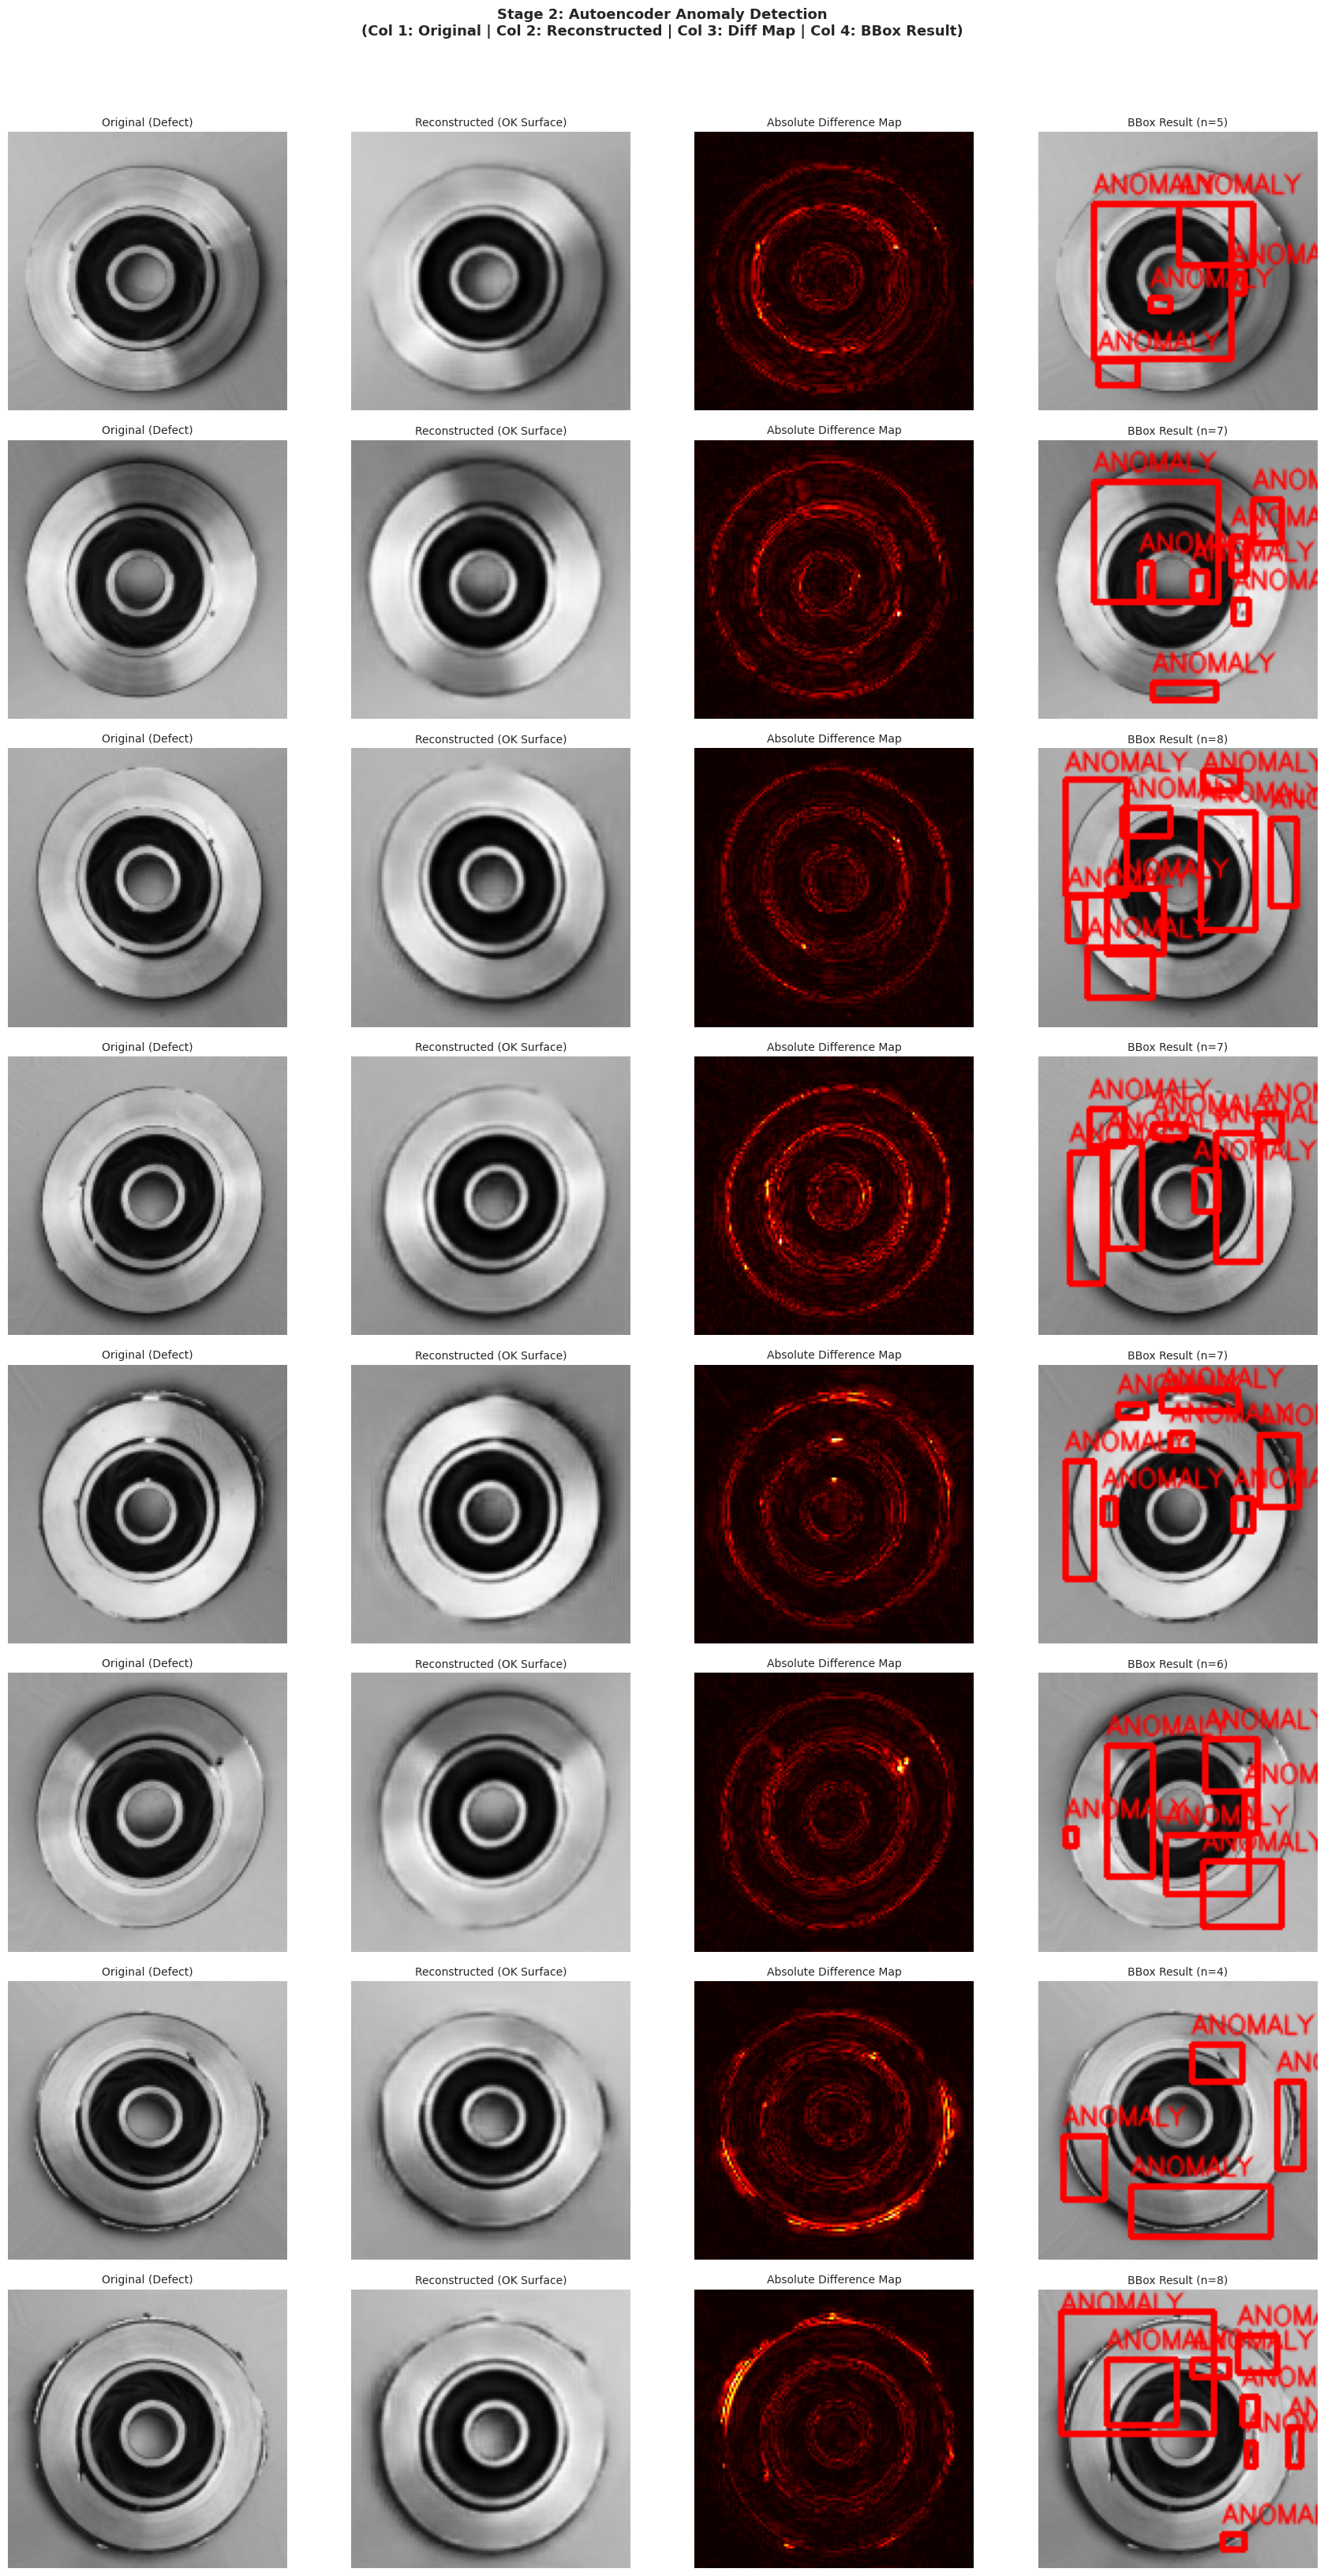

In [ ]:
def localize_defect_autoencoder(img_bgr, model, base_threshold=0.035, min_area=20):
    gray          = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    resized       = cv2.resize(gray, (128, 128))
    norm          = resized.astype(np.float32) / 255.0
    tensor        = np.expand_dims(np.expand_dims(norm, axis=-1), axis=0)

    reconstructed = model.predict(tensor, verbose=0)[0, :, :, 0]
    diff          = cv2.absdiff(norm, reconstructed)
    diff_blur     = cv2.GaussianBlur(diff, (5, 5), 0)

    pct_thresh    = np.percentile(diff_blur, 93)
    dyn_thresh    = max(base_threshold, pct_thresh)
    binary_mask   = (diff_blur > dyn_thresh).astype(np.uint8) * 255

    kernel_open   = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    kernel_close  = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9))
    binary_mask   = cv2.morphologyEx(binary_mask, cv2.MORPH_OPEN,  kernel_open)
    binary_mask   = cv2.morphologyEx(binary_mask, cv2.MORPH_CLOSE, kernel_close)

    binary_mask_r = cv2.resize(binary_mask,
                                (img_bgr.shape[1], img_bgr.shape[0]),
                                interpolation=cv2.INTER_NEAREST)
    contours, _   = cv2.findContours(binary_mask_r, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    boxes         = [cv2.boundingRect(c) for c in contours if cv2.contourArea(c) >= min_area]

    result = img_bgr.copy()
    for (x, y, w, h) in boxes:
        cv2.rectangle(result, (x, y), (x + w, y + h), (0, 0, 255), 2)
        cv2.putText(result, 'ANOMALY', (x, max(y - 5, 10)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 0, 255), 1, cv2.LINE_AA)

    return result, diff, reconstructed, binary_mask_r, boxes

defect_indices    = [i for i, lbl in enumerate(test_ori_labels) if lbl == 1]
np.random.seed(42)
sample_indices_ae = np.random.choice(defect_indices, size=min(8, len(defect_indices)), replace=False)

fig, axes = plt.subplots(len(sample_indices_ae), 4,
                          figsize=(18, len(sample_indices_ae) * 4))
fig.suptitle(
    'Stage 2: Autoencoder Anomaly Detection\n'
    '(Col 1: Original | Col 2: Reconstructed | Col 3: Diff Map | Col 4: BBox Result)',
    fontsize=13, fontweight='bold', y=1.02)

for row, idx in enumerate(sample_indices_ae):
    img_bgr = test_ori_imgs[idx]
    result, diff, recon, mask, boxes = localize_defect_autoencoder(
        img_bgr, autoencoder, base_threshold=0.035, min_area=20)

    axes[row, 0].imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    axes[row, 0].set_title('Original (Defect)', fontsize=10)
    axes[row, 0].axis('off')

    axes[row, 1].imshow(recon, cmap='gray')
    axes[row, 1].set_title('Reconstructed (OK Surface)', fontsize=10)
    axes[row, 1].axis('off')

    axes[row, 2].imshow(diff, cmap='hot')
    axes[row, 2].set_title('Absolute Difference Map', fontsize=10)
    axes[row, 2].axis('off')

    axes[row, 3].imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
    axes[row, 3].set_title(f'BBox Result (n={len(boxes)})', fontsize=10)
    axes[row, 3].axis('off')

plt.tight_layout()
plt.savefig('autoencoder_results.png', dpi=150, bbox_inches='tight')
plt.show()

## Autoencoder Performance Summary

In [ ]:
np.random.seed(42)
eval_indices = np.random.choice(defect_indices, size=min(200, len(defect_indices)), replace=False)
bbox_counts  = []

for idx in eval_indices:
    _, _, _, _, boxes = localize_defect_autoencoder(
        test_ori_imgs[idx], autoencoder, base_threshold=0.035, min_area=20)
    bbox_counts.append(len(boxes))

bbox_counts = np.array(bbox_counts)

print("STAGE 2 SUMMARY: AUTOENCODER ANOMALY DETECTION")
print(f"Evaluated on {len(eval_indices)} defective samples\n")
print(f"  Average bboxes per image       : {bbox_counts.mean():.2f}")
print(f"  Images with >=1 bbox (Success) : {(bbox_counts >= 1).sum()} / {len(eval_indices)} "
      f"({(bbox_counts >= 1).mean() * 100:.1f}%)")
print(f"  Images with no bbox (Missed)   : {(bbox_counts == 0).sum()} / {len(eval_indices)}")
print(f"  Max bboxes in one image        : {bbox_counts.max()}")

del train_ori_imgs, train_ori_labels, test_ori_imgs, test_ori_labels
gc.collect()
print("Cleanup complete.")

STAGE 2 SUMMARY: AUTOENCODER ANOMALY DETECTION
Evaluated on 200 defective samples

  Average bboxes per image       : 5.91
  Images with >=1 bbox (Success) : 200 / 200 (100.0%)
  Images with no bbox (Missed)   : 0 / 200
  Max bboxes in one image        : 13
Cleanup complete.


In [ ]:
import os, json, zipfile
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cv2, numpy as np
from google.colab import files

SAVE_DIR = 'dashboard_assets'
os.makedirs(SAVE_DIR, exist_ok=True)


print("  SAVING ALL DASHBOARD ASSETS")


joblib.dump(svm_ori,     f'{SAVE_DIR}/svm_ori.pkl')
joblib.dump(svm_noise,   f'{SAVE_DIR}/svm_noise.pkl')
joblib.dump(scaler_ori,  f'{SAVE_DIR}/scaler_ori.pkl')
joblib.dump(scaler_noise,f'{SAVE_DIR}/scaler_noise.pkl')
print(" [1/7] SVM models & scalers saved")


autoencoder.save(f'{SAVE_DIR}/autoencoder_defect.h5')
print(" [2/7] Autoencoder model saved")

summary_df.to_csv(f'{SAVE_DIR}/robustness_summary.csv')
summary_df.reset_index().to_json(
    f'{SAVE_DIR}/robustness_summary.json', orient='records', indent=2)
print(" [3/7] Robustness summary (CSV + JSON) saved")

fig, ax = plt.subplots(figsize=(14, 5))
summary_df[['Accuracy (%)', 'Recall (%)', 'F1-Score (%)']].plot(
    kind='bar', ax=ax, colormap='viridis', width=0.7, edgecolor='white')
ax.set_title("Model Robustness Summary Across All Scenarios",
             fontsize=13, fontweight='bold')
ax.set_ylabel("Score (%)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right', fontsize=8)
ax.legend(loc='lower right', fontsize=9)
ax.set_ylim(0, 115)
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=7, rotation=90)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/robustness_bar_chart.png', dpi=150, bbox_inches='tight')
plt.close()
print(" [4/7] Robustness bar chart PNG saved")


try:
    _ = test_ori_imgs
except NameError:
    print("  → Reloading test images for visualization...")
    test_ori_imgs, test_ori_labels = load_data(test_path)

defect_indices = [i for i, lbl in enumerate(test_ori_labels) if lbl == 1]
np.random.seed(42)
sample_vis = np.random.choice(defect_indices, size=min(6, len(defect_indices)), replace=False)

fig, axes = plt.subplots(6, 4, figsize=(18, 6 * 4))
fig.suptitle('Stage 2: Autoencoder Defect Localization\n'
             '(Original | Reconstructed | Diff Map | BBox Result)',
             fontsize=13, fontweight='bold', y=1.01)

for row, idx in enumerate(sample_vis):
    img_bgr = test_ori_imgs[idx]
    result, diff, recon, mask, boxes = localize_defect_autoencoder(
        img_bgr, autoencoder, base_threshold=0.035, min_area=20)

    axes[row, 0].imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    axes[row, 0].set_title('Original (Defect)', fontsize=9); axes[row, 0].axis('off')

    axes[row, 1].imshow(recon, cmap='gray')
    axes[row, 1].set_title('Reconstructed (OK)', fontsize=9); axes[row, 1].axis('off')

    axes[row, 2].imshow(diff, cmap='hot')
    axes[row, 2].set_title('Abs Diff Map', fontsize=9); axes[row, 2].axis('off')

    axes[row, 3].imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
    axes[row, 3].set_title(f'BBox ({len(boxes)} region)', fontsize=9); axes[row, 3].axis('off')

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/autoencoder_bbox_samples.png', dpi=150, bbox_inches='tight')
plt.close()
print(" [5/7] Autoencoder BBox sample visualization PNG saved")

np.random.seed(42)
vis_idx = np.random.choice(len(test_zoom_imgs), size=6, replace=False)
fig, axes = plt.subplots(2, 6, figsize=(18, 6))
fig.suptitle('Scenario 5 — Original vs Random Zoom+Crop',
             fontsize=13, fontweight='bold')
for col, i in enumerate(vis_idx):
    orig_idx = sample_indices_s5[i]
    axes[0, col].imshow(cv2.cvtColor(test_ori_imgs[orig_idx], cv2.COLOR_BGR2RGB))
    axes[0, col].set_title(f'Original\n({reverse_label_map[test_zoom_labels[i]]})', fontsize=8)
    axes[0, col].axis('off')
    axes[1, col].imshow(cv2.cvtColor(test_zoom_imgs[i], cv2.COLOR_BGR2RGB))
    axes[1, col].set_title('Zoom+Crop', fontsize=8)
    axes[1, col].axis('off')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/zoom_crop_samples.png', dpi=150, bbox_inches='tight')
plt.close()
print(" [6/7] Zoom+Crop sample visualization PNG saved")

config = {
    "dataset": {
        "train_images": 6633,
        "test_images": 715,
        "augmented_train": 13266,
        "classes": ["ok_front", "def_front"]
    },
    "stage1_svm": {
        "kernel": "rbf", "C": 10, "gamma": "scale",
        "features": "HOG (9 orient, 8x8 cell, 2x2 block) + LBP (r=3, p=24)",
        "denoising": "Bilateral Filter + NL-Means",
        "augmentation": "Random Zoom+Crop (50-85%) on training set"
    },
    "stage2_autoencoder": {
        "architecture": "Conv Autoencoder (3 Encoder + 3 Decoder layers)",
        "input_size": "128x128 Grayscale",
        "bottleneck": "16x16x128",
        "total_params": 332801,
        "threshold": "np.percentile(diff, 93) with base_threshold=0.035",
        "min_area": 20,
        "success_rate_pct": 100.0
    },
    "robustness_results": summary_df.reset_index().to_dict(orient='records')
}
with open(f'{SAVE_DIR}/dashboard_config.json', 'w') as f:
    json.dump(config, f, indent=2)
print(" [7/7] Dashboard config JSON saved")

zip_path = 'dashboard_assets.zip'
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for root, dirs, filenames in os.walk(SAVE_DIR):
        for filename in filenames:
            filepath = os.path.join(root, filename)
            zf.write(filepath, os.path.relpath(filepath, SAVE_DIR))

print(f"\n{'='*55}")
print(f"  ALL ASSETS SAVED  →  {SAVE_DIR}/")
print(f"  ZIP FILE          →  {zip_path}")
for f in sorted(os.listdir(SAVE_DIR)):
    size = os.path.getsize(os.path.join(SAVE_DIR, f))
    print(f"     {f:<40} {size/1024:.1f} KB")

files.download(zip_path)

  SAVING ALL DASHBOARD ASSETS


 [1/7] SVM models & scalers saved
 [2/7] Autoencoder model saved
 [3/7] Robustness summary (CSV + JSON) saved
 [4/7] Robustness bar chart PNG saved
  → Reloading test images for visualization...
 [5/7] Autoencoder BBox sample visualization PNG saved
 [6/7] Zoom+Crop sample visualization PNG saved
 [7/7] Dashboard config JSON saved

  ALL ASSETS SAVED  →  dashboard_assets/
  ZIP FILE          →  dashboard_assets.zip
     autoencoder_bbox_samples.png             764.6 KB
     autoencoder_defect.h5                    1345.0 KB
     dashboard_config.json                    1.8 KB
     robustness_bar_chart.png                 145.2 KB
     robustness_summary.csv                   0.4 KB
     robustness_summary.json                  0.9 KB
     scaler_noise.pkl                         191.1 KB
     scaler_ori.pkl                           191.1 KB
     svm_noise.pkl                            603098.2 KB
     svm_ori.pkl                              537879.7 KB
     zoom_crop_samples.png    

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>